In [ ]:
# IMPOR PUSTAKA DAN PENGATURAN AWAL
%matplotlib inline
import time
import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from tensorflow.keras import layers, models
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2, VGG16, ResNet50
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as preprocess_mobilenet
from tensorflow.keras.applications.vgg16 import preprocess_input as preprocess_vgg
from tensorflow.keras.applications.resnet50 import preprocess_input as preprocess_resnet

from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize
from sklearn.manifold import TSNE

print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.20.0


In [ ]:
# LOAD DATASET & PREPROCESSING
print("Memuat dataset CIFAR-10...")
(X_train, y_train), (X_test, y_test) = cifar10.load_data()

class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 
               'dog', 'frog', 'horse', 'ship', 'truck']
num_classes = 10

# Normalisasi piksel ke rentang 0-1
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

# One-hot encoding untuk label
y_train_cat = tf.keras.utils.to_categorical(y_train, num_classes)
y_test_cat = tf.keras.utils.to_categorical(y_test, num_classes)

print(f"Bentuk data latih: {X_train.shape}")
print(f"Bentuk data uji: {X_test.shape}")

Memuat dataset CIFAR-10...
Bentuk data latih: (50000, 32, 32, 3)
Bentuk data uji: (10000, 32, 32, 3)


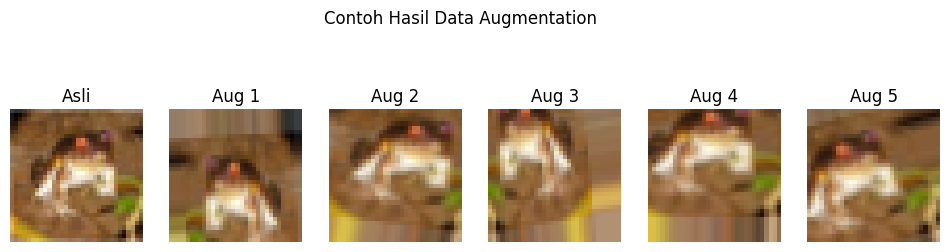

In [ ]:
# DATA AUGMENTATION & VISUALISASI
datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    zoom_range=0.2,
    shear_range=0.2,
    fill_mode='nearest'
)
datagen.fit(X_train)

# Visualisasi sampel augmentasi
sample = X_train[0]
sample_batch = np.expand_dims(sample, axis=0)
aug_iter = datagen.flow(sample_batch, batch_size=1)

plt.figure(figsize=(12, 3))
plt.subplot(1, 6, 1)
plt.imshow(sample)
plt.title("Asli")
plt.axis("off")

for i in range(5):
    aug_img = next(aug_iter)[0]
    plt.subplot(1, 6, i+2)
    plt.imshow(aug_img)
    plt.title(f"Aug {i+1}")
    plt.axis("off")
plt.suptitle("Contoh Hasil Data Augmentation", y=1.05)
plt.show()

In [ ]:
# VARIASI ARSITEKTUR CNN
def build_cnn_v1():
    """Arsitektur Standar"""
    model = models.Sequential([
        layers.Input(shape=(32, 32, 3)),
        layers.Conv2D(32, (3,3), activation='relu', padding='same', name='conv_layer_1'),
        layers.MaxPooling2D(2,2),
        layers.Conv2D(64, (3,3), activation='relu', padding='same', name='conv_layer_2'),
        layers.MaxPooling2D(2,2),
        layers.Conv2D(128, (3,3), activation='relu', padding='same', name='last_conv_layer'),
        layers.Flatten(),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation='softmax')
    ])
    return model

def build_cnn_v2():
    """Arsitektur Lebih Dalam (Deeper) dengan Batch Normalization"""
    model = models.Sequential([
        layers.Input(shape=(32, 32, 3)),
        layers.Conv2D(64, (3,3), activation='relu', padding='same', name='conv_layer_1'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2,2),
        layers.Conv2D(128, (3,3), activation='relu', padding='same', name='conv_layer_2'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2,2),
        layers.Conv2D(256, (3,3), activation='relu', padding='same', name='last_conv_layer'),
        layers.GlobalAveragePooling2D(),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation='softmax')
    ])
    return model

model_summary_test = build_cnn_v1()
model_summary_test.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv_layer_1 (Conv2D)           │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_layer_2 (Conv2D)           │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ last_conv_layer (Conv2D)        │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     2,097,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,193,226 (8.37 MB)

 Trainable params: 2,193,226 (8.37 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# PELATIHAN MODEL 0 (NO AUG) & MODEL 1 (AUG)
epochs_scratch = 10
batch_size = 64

# --- Model 0: Tanpa Augmentasi (Baseline untuk cek overfitting) ---
print("Melatih Model 0: CNN V1 TANPA Augmentasi...")
model_no_aug = build_cnn_v1()
model_no_aug.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
history_no_aug = model_no_aug.fit(X_train, y_train_cat, batch_size=batch_size, 
                                  epochs=epochs_scratch, validation_data=(X_test, y_test_cat), verbose=0)
print("Model 0 selesai.")

# --- Model 1: Dengan Augmentasi (Adam, LR=0.001) ---
print("\nMelatih Model 1: CNN V1 DENGAN Augmentasi (Adam)...")
start_train = time.time()
model_1 = build_cnn_v1()
model_1.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
                loss='categorical_crossentropy', metrics=['accuracy'])
history_1 = model_1.fit(datagen.flow(X_train, y_train_cat, batch_size=batch_size),
                        epochs=epochs_scratch, validation_data=(X_test, y_test_cat), verbose=1)
waktu_train_model1 = time.time() - start_train
print("Model 1 selesai.")

Melatih Model 0: CNN V1 TANPA Augmentasi...
Model 0 selesai.

Melatih Model 1: CNN V1 DENGAN Augmentasi (Adam)...
Epoch 1/10


c:\Users\aa870\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


782/782 ━━━━━━━━━━━━━━━━━━━━ 19s 24ms/step - accuracy: 0.2902 - loss: 1.9081 - val_accuracy: 0.4661 - val_loss: 1.4466
Epoch 2/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 18s 23ms/step - accuracy: 0.4421 - loss: 1.5342 - val_accuracy: 0.5282 - val_loss: 1.2857
Epoch 3/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 18s 24ms/step - accuracy: 0.5009 - loss: 1.3838 - val_accuracy: 0.5600 - val_loss: 1.2052
Epoch 4/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 19s 24ms/step - accuracy: 0.5371 - loss: 1.2940 - val_accuracy: 0.6408 - val_loss: 1.0016
Epoch 5/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 21s 27ms/step - accuracy: 0.5607 - loss: 1.2386 - val_accuracy: 0.6395 - val_loss: 1.0007
Epoch 6/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 20s 26ms/step - accuracy: 0.5848 - loss: 1.1852 - val_accuracy: 0.6477 - val_loss: 0.9825
Epoch 7/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 19s 24ms/step - accuracy: 0.5996 - loss: 1.1235 - val_accuracy: 0.6573 - val_loss: 0.9699
Epoch 8/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 19s 24ms/step - accuracy: 0.6146 - loss: 1.0872 - val_accurac

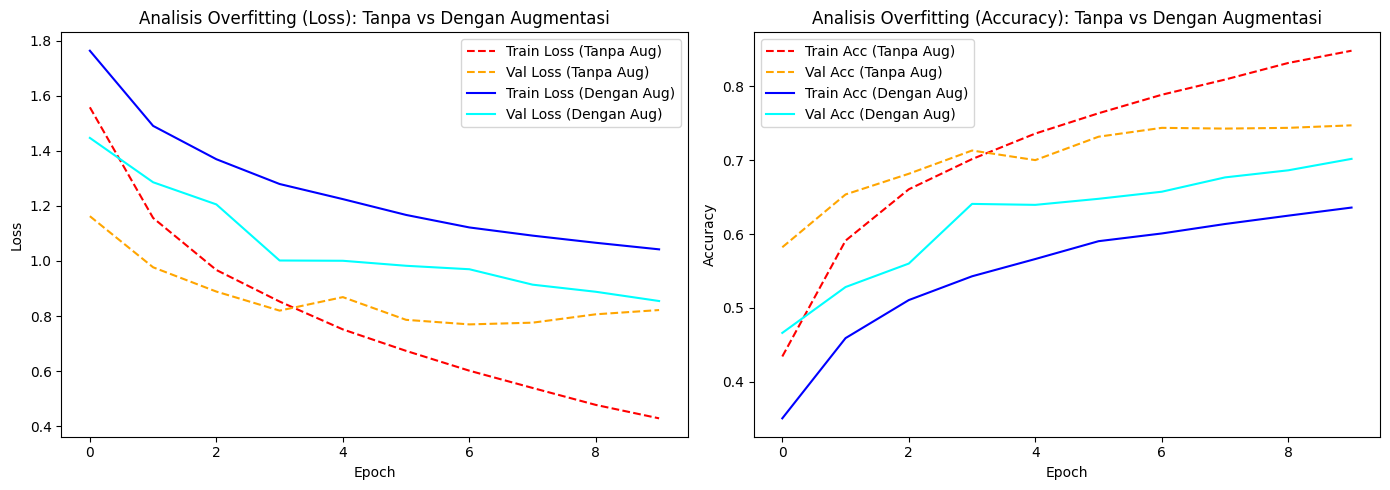

In [ ]:
# GRAFIK LEARNING CURVE (ANALISIS OVERFITTING)
plt.figure(figsize=(14, 5))

# Plot Loss
plt.subplot(1, 2, 1)
plt.plot(history_no_aug.history['loss'], label='Train Loss (Tanpa Aug)', linestyle='--', color='red')
plt.plot(history_no_aug.history['val_loss'], label='Val Loss (Tanpa Aug)', linestyle='--', color='orange')
plt.plot(history_1.history['loss'], label='Train Loss (Dengan Aug)', color='blue')
plt.plot(history_1.history['val_loss'], label='Val Loss (Dengan Aug)', color='cyan')
plt.title("Analisis Overfitting (Loss): Tanpa vs Dengan Augmentasi")
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Plot Accuracy
plt.subplot(1, 2, 2)
plt.plot(history_no_aug.history['accuracy'], label='Train Acc (Tanpa Aug)', linestyle='--', color='red')
plt.plot(history_no_aug.history['val_accuracy'], label='Val Acc (Tanpa Aug)', linestyle='--', color='orange')
plt.plot(history_1.history['accuracy'], label='Train Acc (Dengan Aug)', color='blue')
plt.plot(history_1.history['val_accuracy'], label='Val Acc (Dengan Aug)', color='cyan')
plt.title("Analisis Overfitting (Accuracy): Tanpa vs Dengan Augmentasi")
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
# PELATIHAN MODEL 2 (SGD) & MODEL 3 (DEEPER CNN)
print("Melatih Model 2: CNN V1 dengan SGD (LR=0.01, Momentum=0.9)...")
model_2 = build_cnn_v1()
model_2.compile(optimizer=tf.keras.optimizers.SGD(learning_rate=0.01, momentum=0.9),
                loss='categorical_crossentropy', metrics=['accuracy'])
history_2 = model_2.fit(datagen.flow(X_train, y_train_cat, batch_size=batch_size),
                        epochs=epochs_scratch, validation_data=(X_test, y_test_cat), verbose=0)
print("Model 2 selesai.")

print("\nMelatih Model 3: CNN V2 Deeper dengan Adam...")
model_3 = build_cnn_v2()
model_3.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
                loss='categorical_crossentropy', metrics=['accuracy'])
history_3 = model_3.fit(datagen.flow(X_train, y_train_cat, batch_size=batch_size),
                        epochs=epochs_scratch, validation_data=(X_test, y_test_cat), verbose=0)
print("Model 3 selesai.")

Melatih Model 2: CNN V1 dengan SGD (LR=0.01, Momentum=0.9)...
Model 2 selesai.

Melatih Model 3: CNN V2 Deeper dengan Adam...
Model 3 selesai.


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step

--- CLASSIFICATION REPORT (MODEL 1) ---
              precision    recall  f1-score   support

    airplane       0.75      0.76      0.76      1000
  automobile       0.74      0.91      0.82      1000
        bird       0.83      0.38      0.52      1000
         cat       0.61      0.38      0.47      1000
        deer       0.65      0.63      0.64      1000
         dog       0.65      0.57      0.61      1000
        frog       0.63      0.85      0.72      1000
       horse       0.66      0.85      0.74      1000
        ship       0.82      0.82      0.82      1000
       truck       0.72      0.86      0.79      1000

    accuracy                           0.70     10000
   macro avg       0.71      0.70      0.69     10000
weighted avg       0.71      0.70      0.69     10000



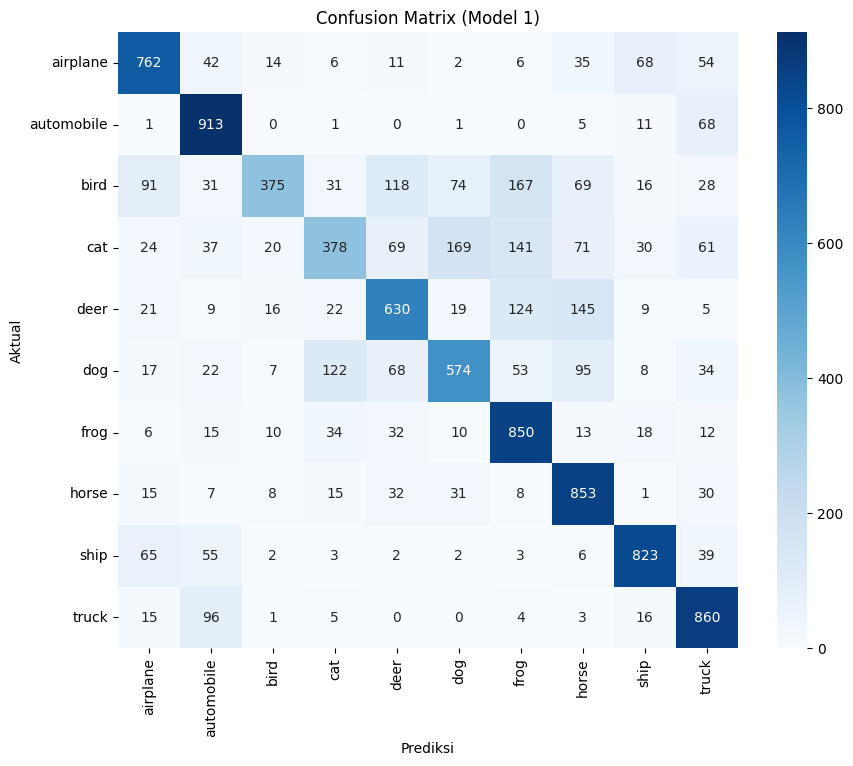

In [ ]:
# INFERENCE TIME & CONFUSION MATRIX
start_inf = time.time()
y_pred = model_1.predict(X_test)
waktu_inf_model1 = time.time() - start_inf
y_pred_classes = np.argmax(y_pred, axis=1)

print("\n--- CLASSIFICATION REPORT (MODEL 1) ---")
print(classification_report(y_test, y_pred_classes, target_names=class_names))

cm = confusion_matrix(y_test, y_pred_classes)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title("Confusion Matrix (Model 1)")
plt.ylabel("Aktual")
plt.xlabel("Prediksi")
plt.show()

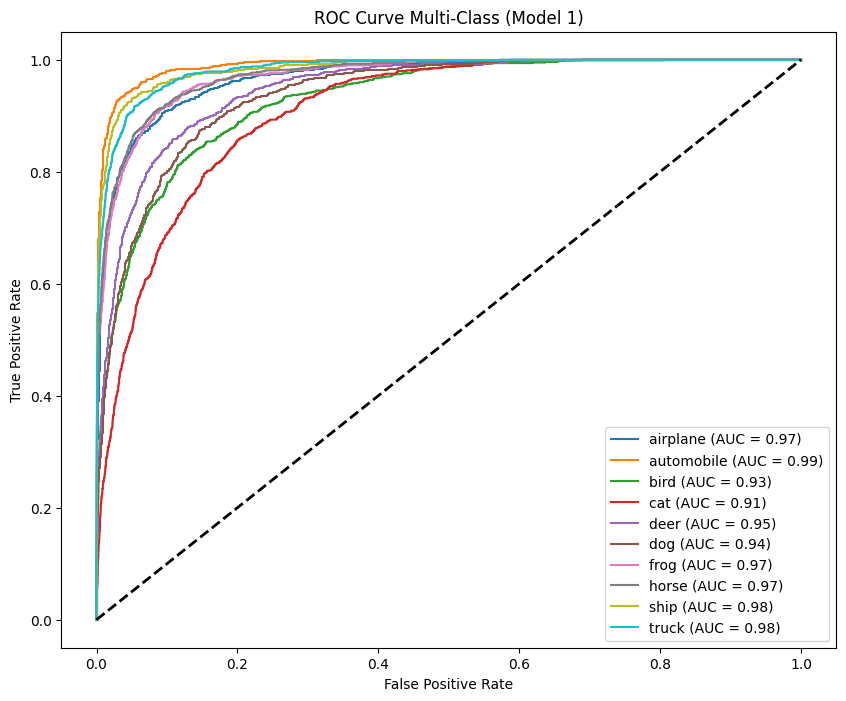

In [ ]:
# ROC CURVE MULTI-CLASS
y_test_bin = label_binarize(y_test, classes=np.arange(num_classes))
plt.figure(figsize=(10, 8))
for i in range(num_classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_pred[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{class_names[i]} (AUC = {roc_auc:.2f})')

plt.plot([0,1], [0,1], 'k--', lw=2)
plt.title("ROC Curve Multi-Class (Model 1)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.show()

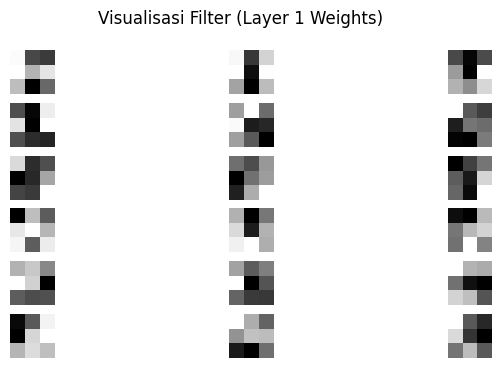

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step


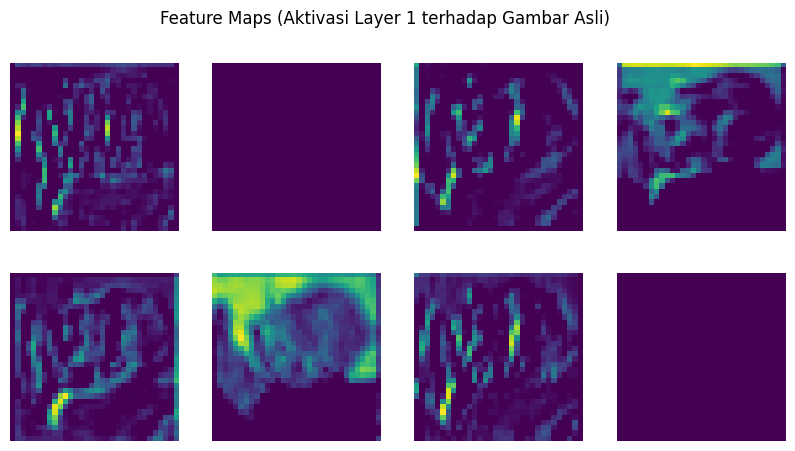

In [ ]:
# VISUALISASI FILTER & FEATURE MAPS
sample_img = X_test[0]
img_tensor = np.expand_dims(sample_img, axis=0)

# 1. Filter Visualization (Bobot)
filters, biases = model_1.get_layer('conv_layer_1').get_weights()
f_min, f_max = filters.min(), filters.max()
filters = (filters - f_min) / (f_max - f_min)

plt.figure(figsize=(8, 4))
for i in range(6): 
    f = filters[:, :, :, i]
    for j in range(3): 
        plt.subplot(6, 3, i*3 + j + 1)
        plt.imshow(f[:, :, j], cmap='gray')
        plt.axis('off')
plt.suptitle("Visualisasi Filter (Layer 1 Weights)")
plt.show()

# 2. Feature Maps (Aktivasi)
activation_model = tf.keras.Model(inputs=model_1.inputs, 
                                  outputs=model_1.get_layer('conv_layer_1').output)
activations = activation_model.predict(img_tensor)
fig, axes = plt.subplots(2, 4, figsize=(10, 5))
for i, ax in enumerate(axes.flat):
    ax.imshow(activations[0, :, :, i], cmap='viridis')
    ax.axis("off")
plt.suptitle("Feature Maps (Aktivasi Layer 1 terhadap Gambar Asli)")
plt.show()

c:\Users\aa870\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\models\functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor_20']
Received: inputs=Tensor(shape=(1, 32, 32, 3))
  warnings.warn(msg)


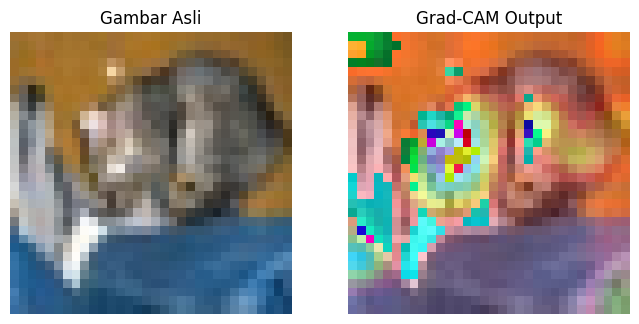

In [ ]:
# GRAD-CAM
def make_gradcam_heatmap(img_array, model, last_conv_layer_name):
    grad_model = tf.keras.models.Model(
        inputs=model.inputs,
        outputs=[model.get_layer(last_conv_layer_name).output, model.outputs[0]]
    )
    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        pred_index = tf.argmax(predictions[0])
        class_channel = predictions[:, pred_index]
    grads = tape.gradient(class_channel, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0,1,2))
    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0)
    heatmap /= tf.math.reduce_max(heatmap)
    return heatmap.numpy()

heatmap = make_gradcam_heatmap(img_tensor, model_1, 'last_conv_layer')
heatmap_resized = cv2.resize(heatmap, (32, 32))
heatmap_resized = np.uint8(255 * heatmap_resized)
heatmap_colored = cv2.applyColorMap(heatmap_resized, cv2.COLORMAP_JET)
superimposed_img = heatmap_colored * 0.4 + (sample_img * 255)

plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1)
plt.imshow(sample_img)
plt.title("Gambar Asli")
plt.axis("off")
plt.subplot(1, 2, 2)
plt.imshow(superimposed_img.astype("uint8"))
plt.title("Grad-CAM Output")
plt.axis("off")
plt.show()

Membuat visualisasi t-SNE (Membutuhkan beberapa detik)...
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


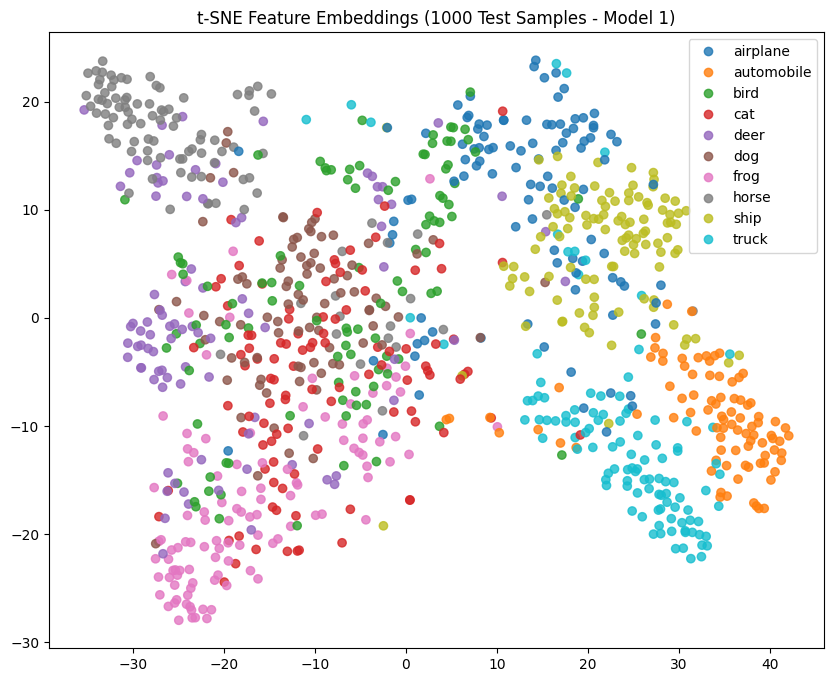

In [ ]:
# t-SNE FEATURE EMBEDDINGS
print("Membuat visualisasi t-SNE (Membutuhkan beberapa detik)...")
feature_extractor = tf.keras.Model(inputs=model_1.inputs, outputs=model_1.layers[-2].output)
features = feature_extractor.predict(X_test[:1000])
tsne = TSNE(n_components=2, random_state=42)
tsne_results = tsne.fit_transform(features)

plt.figure(figsize=(10, 8))
scatter = plt.scatter(tsne_results[:,0], tsne_results[:,1], c=y_test[:1000].flatten(), cmap='tab10', alpha=0.8)
plt.legend(handles=scatter.legend_elements()[0], labels=class_names, loc="best")
plt.title("t-SNE Feature Embeddings (1000 Test Samples - Model 1)")
plt.show()

In [ ]:
# TRANSFER LEARNING - VGG16 (FEATURE EXTRACTION + FINE TUNING)
def build_tl_model(base_model_class, preprocess_func):
    inputs = layers.Input(shape=(32, 32, 3))
    x = layers.UpSampling2D(size=(3,3))(inputs) # Resize paksa 32x32 jadi 96x96 (Minimum model besar)
    x = preprocess_func(x * 255.0) 
    
    base_model = base_model_class(weights='imagenet', include_top=False, input_shape=(96,96,3))
    base_model.trainable = False # FEATURE EXTRACTION mode
    
    x = base_model(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    
    model = tf.keras.Model(inputs, outputs)
    return model, base_model

print("1. Melatih VGG16 (Tahap Feature Extraction)...")
model_vgg, base_vgg = build_tl_model(VGG16, preprocess_vgg)
model_vgg.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model_vgg.fit(X_train, y_train_cat, validation_data=(X_test, y_test_cat), epochs=3, batch_size=128, verbose=1)

print("\n2. Melakukan Fine-Tuning pada VGG16 (Unfreeze blok terakhir)...")
base_vgg.trainable = True
for layer in base_vgg.layers[:-4]: 
    layer.trainable = False # Hanya layer 4 terakhir yang bisa di-train

# Learning rate harus dikecilkan saat fine tuning agar bobot imagenet tidak hancur
model_vgg.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5), 
                  loss='categorical_crossentropy', metrics=['accuracy'])
model_vgg.fit(X_train, y_train_cat, validation_data=(X_test, y_test_cat), epochs=2, batch_size=128, verbose=1)

_, vgg_acc = model_vgg.evaluate(X_test, y_test_cat, verbose=0)
print(f"Akurasi VGG16 setelah Fine-Tuning: {vgg_acc:.4f}")

1. Melatih VGG16 (Tahap Feature Extraction)...
Epoch 1/3
391/391 ━━━━━━━━━━━━━━━━━━━━ 708s 2s/step - accuracy: 0.3483 - loss: 7.2935 - val_accuracy: 0.7145 - val_loss: 1.0350
Epoch 2/3
391/391 ━━━━━━━━━━━━━━━━━━━━ 505s 1s/step - accuracy: 0.6227 - loss: 1.5385 - val_accuracy: 0.7405 - val_loss: 0.7949
Epoch 3/3
391/391 ━━━━━━━━━━━━━━━━━━━━ 385s 984ms/step - accuracy: 0.6582 - loss: 1.1056 - val_accuracy: 0.7415 - val_loss: 0.7660

2. Melakukan Fine-Tuning pada VGG16 (Unfreeze blok terakhir)...
Epoch 1/2
391/391 ━━━━━━━━━━━━━━━━━━━━ 438s 1s/step - accuracy: 0.7057 - loss: 0.8827 - val_accuracy: 0.8272 - val_loss: 0.5184
Epoch 2/2
391/391 ━━━━━━━━━━━━━━━━━━━━ 435s 1s/step - accuracy: 0.7990 - loss: 0.5891 - val_accuracy: 0.8503 - val_loss: 0.4451
Akurasi VGG16 setelah Fine-Tuning: 0.8503


In [ ]:
# TRANSFER LEARNING LAINNYA & KESIMPULAN AKHIR
print("Melatih ResNet50 (Feature Extraction - 3 Epochs)...")
model_resnet, _ = build_tl_model(ResNet50, preprocess_resnet)
model_resnet.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model_resnet.fit(X_train, y_train_cat, validation_data=(X_test, y_test_cat), epochs=3, batch_size=128, verbose=0)
_, res_acc = model_resnet.evaluate(X_test, y_test_cat, verbose=0)

print("Melatih MobileNetV2 (Feature Extraction - 3 Epochs)...")
model_mobilenet, _ = build_tl_model(MobileNetV2, preprocess_mobilenet)
model_mobilenet.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model_mobilenet.fit(X_train, y_train_cat, validation_data=(X_test, y_test_cat), epochs=3, batch_size=128, verbose=0)
_, mob_acc = model_mobilenet.evaluate(X_test, y_test_cat, verbose=0)

# REKAPITULASI
print("\n==================================================")
print("HASIL AKHIR PERBANDINGAN SEMUA MODEL")
print("==================================================")
_, acc_no_aug = model_no_aug.evaluate(X_test, y_test_cat, verbose=0)
_, acc_1 = model_1.evaluate(X_test, y_test_cat, verbose=0)
_, acc_2 = model_2.evaluate(X_test, y_test_cat, verbose=0)
_, acc_3 = model_3.evaluate(X_test, y_test_cat, verbose=0)

print(f"0. CNN V1 (Baseline, No Aug)           : {acc_no_aug:.4f}")
print(f"1. CNN V1 (Adam, LR=0.001, Augmentasi) : {acc_1:.4f}")
print(f"2. CNN V1 (SGD, LR=0.01)               : {acc_2:.4f}")
print(f"3. CNN V2 Deeper (Adam)                : {acc_3:.4f}")
print(f"4. VGG16 (Dengan Fine-Tuning)          : {vgg_acc:.4f}")
print(f"5. ResNet50 (Feature Extraction)       : {res_acc:.4f}")
print(f"6. MobileNetV2 (Feature Extraction)    : {mob_acc:.4f}")
print("--------------------------------------------------")
print(f"Waktu Training (CNN V1 Model 1)        : {waktu_train_model1:.2f} detik")
print(f"Waktu Inference (CNN V1 Model 1)       : {waktu_inf_model1:.2f} detik")
print("==================================================")

Melatih ResNet50 (Feature Extraction - 3 Epochs)...
Melatih MobileNetV2 (Feature Extraction - 3 Epochs)...

HASIL AKHIR PERBANDINGAN SEMUA MODEL
0. CNN V1 (Baseline, No Aug)           : 0.7472
1. CNN V1 (Adam, LR=0.001, Augmentasi) : 0.7018
2. CNN V1 (SGD, LR=0.01)               : 0.6826
3. CNN V2 Deeper (Adam)                : 0.7048
4. VGG16 (Dengan Fine-Tuning)          : 0.8503
5. ResNet50 (Feature Extraction)       : 0.7707
6. MobileNetV2 (Feature Extraction)    : 0.7754
--------------------------------------------------
Waktu Training (CNN V1 Model 1)        : 190.55 detik
Waktu Inference (CNN V1 Model 1)       : 1.00 detik
